# SMM Estimation
Structural estimation of `FullLaborModelClass` via Simulated Method of Moments.

**Workflow**
1. Initialise model and estimator  
2. Set starting values `theta0`  
3. Load data moments  
4. Verify moment function at `theta0`  
5. Run estimation (Nelder-Mead)  
6. Plot simulated vs empirical hazards  
7. Inspect parameter estimates

## 1. Setup

In [48]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from DynLaborSickModel import FullLaborModelClass
from Estimation import SMMEstimator, make_data_moments, make_weight_matrix, moment_fit_table, PARAM_SPEC 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Initialise estimator

In [49]:

est = SMMEstimator(
    FullLaborModelClass,
    calibrated = {
        'beta':    0.98,
        'tau':     0.30,
        'Ubar':    24,
        'alpha':   0.10,   # calibrated from Mincer wage regression
        'delta_k': 0.05,   # calibrated depreciation rate
    },
)

pd.DataFrame(PARAM_SPEC, columns=['name','lower','upper','description'])


,name,lower,upper,description
0,psi,0.05,1.500,job-finding scale
1,gamma,0.30,2.500,search cost curvature
2,iota,0.30,2.500,work disutility curvature
3,chi,0.00,6.000,participation cost coefficient
4,rho_h,0.50,0.995,health AR(1) persistence
5,sigma_h,0.05,1.200,health shock std dev
6,delta_h_S,-0.10,1.000,health recovery drift on sick leave
7,delta0_doc,-0.20,0.600,medical gate intercept
8,delta1_doc,-1.00,2.000,medical gate slope (health)
9,delta2_doc,-2.00,2.000,medical gate curvature (health²)


## 3. Starting values
Set `theta0` to the default model parameter values.  
Adjust individual entries here before running estimation.

In [50]:

_m = FullLaborModelClass()
_m.setup()
_p = _m.par

theta0 = np.array([
    _p.psi,            # job-finding scale
    _p.gamma,          # search cost curvature
    _p.iota,           # work disutility curvature
    _p.chi,            # participation cost coefficient
    _p.rho_h,          # health AR(1) persistence
    _p.sigma_h,        # health shock std dev
    _p.delta_h_S,      # health recovery drift on sick leave
    _p.delta0_doc,     # medical gate intercept
    _p.delta1_doc,     # medical gate slope (health)
    _p.delta2_doc,     # medical gate curvature (health²)
    _p.b_sick_low,     # intermediate benefit post-reassessment
    _p.delta0_low,     # P(reduced benefit | h) intercept
    _p.delta1_low,     # P(reduced benefit | h) slope
    _p.delta2_low,     # P(reduced benefit | h) curvature
    _p.delta0_out,     # P(kicked out | h) intercept
    _p.delta1_out,     # P(kicked out | h) slope
    _p.delta2_out,     # P(kicked out | h) curvature
    _p.lambda_grid[0], # search cost scale type 0
    _p.lambda_grid[1], # search cost scale type 1
    _p.nu_grid[0],     # work disutility scale type 0
    _p.nu_grid[1],     # work disutility scale type 1
    _p.type_shares[1], # population share of type 1
    _p.h_init_mu[1],   # initial health z-shift type 1
])

# Print starting values alongside bounds
spec = pd.DataFrame(PARAM_SPEC, columns=['name','lower','upper','description'])
spec.insert(1, 'theta0', theta0)
spec


,name,theta0,lower,upper,description
0,psi,1.000,0.05,1.500,job-finding scale
1,gamma,0.900,0.30,2.500,search cost curvature
2,iota,0.900,0.30,2.500,work disutility curvature
3,chi,1.000,0.00,6.000,participation cost coefficient
4,rho_h,0.915,0.50,0.995,health AR(1) persistence
5,sigma_h,0.300,0.05,1.200,health shock std dev
6,delta_h_S,0.060,-0.10,1.000,health recovery drift on sick leave
7,delta0_doc,0.150,-0.20,0.600,medical gate intercept
8,delta1_doc,0.900,-1.00,2.000,medical gate slope (health)
9,delta2_doc,0.000,-2.00,2.000,medical gate curvature (health²)


## 4. Data moments
Load empirical hazard rates.  Add more moment DataFrames here as they become available —
anything left `None` is automatically excluded from the objective.

In [51]:
# ── U→E and U→S ──────────────────────────────────────────────────────────                                                                                                                             
_ue = pd.read_csv('hazard_UE.csv')                                                                                                                                                                      
_us = pd.read_csv('hazard_US.csv')
                                                                                                                                                                                                        
# ── S→E and S→U (replaces hazard_monthly.csv + weight_monthly.csv) ───────                                                                                                                             
_se = pd.read_csv('hazard_SE.csv')
_su = pd.read_csv('hazard_SU.csv')
_se = _se[_se['hazard'] > 0].rename(columns={'duration_m': 'duration'})
_su = _su[_su['hazard'] > 0].rename(columns={'duration_m': 'duration'})
_se['duration'] = _se['duration'].round().astype(int)
_su['duration'] = _su['duration'].round().astype(int)
# Keep only one row per integer month (first occurrence after rounding)
_se = _se.drop_duplicates('duration')
_su = _su.drop_duplicates('duration')                                                                                                                                                                
                
# anc_ved_afgang is 0-indexed → add 1; trim to 24 months                                                                                                                                                
for _df in [_ue, _us]:
    _df['duration'] = _df['anc_ved_afgang'].round().astype(int) + 1         

est_t = 30
                                                                                                                                                                                                        
_ue = _ue[_ue['duration'] <= est_t].reset_index(drop=True)                                                                                                                                                                        
_us = _us[_us['duration'] <= est_t].reset_index(drop=True)                                                                                                                                                                        
_se = _se[_se['duration'] <= est_t].reset_index(drop=True)                                                                                                                                                                        
_su = _su[_su['duration'] <= est_t].reset_index(drop=True)
                                                                                                                                                                                                        
# ── Build data moments ────────────────────────────────────────────────────
data_moments = make_data_moments(                                                                                                                                                                       
    hz_ue_df = _ue[['duration', 'hazard']],                                                                                                                                                             
    hz_us_df = _us[['duration', 'hazard']],                                                                                                                                                             
    hz_se_df = _se[['duration', 'hazard']],                                                                                                                                                             
    hz_su_df = _su[['duration', 'hazard']],                                                                                                                                                             
)                                                                                                                                                                                                       

# ── Build SE dict and weight matrix (1/se²) ───────────────────────────────                                                                                                                            
se_dict = {}    
for prefix, _df in [('hz_ue', _ue), ('hz_us', _us), ('hz_se', _se), ('hz_su', _su)]:                                                                                                                    
    for _, row in _df.iterrows():                                                                                                                                                                       
        se_dict[f"{prefix}_d{int(row['duration']):02d}"] = row['hazard_se']                                                                                                                             
                                                                                                                                                                                                        
W_se = make_weight_matrix(se_dict, data_moments)                                                                                                                                                        
                                                                                                                                                                                                        
print(f'{len(data_moments)} moments loaded, {len(se_dict)} with standard errors') 

# ── Build CI dict from all hazard files ───────────────────────────────────
ci_dict = {}
for prefix, _df in [('hz_ue', _ue), ('hz_us', _us), ('hz_se', _se), ('hz_su', _su)]:
    for _, row in _df.iterrows():
        k = f"{prefix}_d{int(row['duration']):02d}"
        ci_dict[k] = (row['hazard_lower'], row['hazard_upper'])

24 moments loaded:
  hz_se_d01                 0.2948
  hz_se_d02                 0.2568
  hz_se_d03                 0.2562
  hz_se_d04                 0.2504
  hz_se_d05                 0.2462
  hz_se_d06                 0.2630
  hz_se_d07                 0.2914
  hz_se_d08                 0.2234
  hz_se_d09                 0.2323
  hz_se_d10                 0.2111
  hz_se_d11                 0.2094
  hz_se_d12                 0.1871
  hz_se_d13                 0.1862
  hz_se_d14                 0.1694
  hz_se_d15                 0.1610
  hz_se_d16                 0.1561
  hz_se_d17                 0.1702
  hz_se_d18                 0.1607
  hz_se_d19                 0.1652
  hz_se_d20                 0.1664
  hz_se_d21                 0.1340
  hz_se_d22                 0.1280
  hz_se_d23                 0.1426
  hz_se_d24                 0.1283

Weighting matrix: (24, 24)


## 5. Verify moment function at starting values
Runs the model once at `theta0` to confirm everything works before estimation.

In [52]:
m0 = est.compute_moments(theta0)

fit0 = moment_fit_table(m0, data_moments)
print(f'Q at theta0 = {est.objective(theta0, data_moments, W_se):.6f}\n')
display(fit0)

Q at theta0 = 0.097698



,data,model,deviation,rel_dev_%
moment,,,,
hz_se_d02,0.256777,0.237728,-0.019049,-7.418489
hz_se_d03,0.256217,0.205247,-0.050970,-19.893270
hz_se_d04,0.250364,0.183611,-0.066752,-26.662158
hz_se_d05,0.246224,0.168425,-0.077799,-31.596794
hz_se_d06,0.263007,0.158167,-0.104840,-39.862043
hz_se_d07,0.291352,0.319897,0.028545,9.797333
hz_se_d08,0.223415,0.282202,0.058788,26.313276
hz_se_d09,0.232273,0.112214,-0.120060,-51.688990
hz_se_d10,0.211096,0.118307,-0.092790,-43.956180


## 6. Plot hazards at starting values

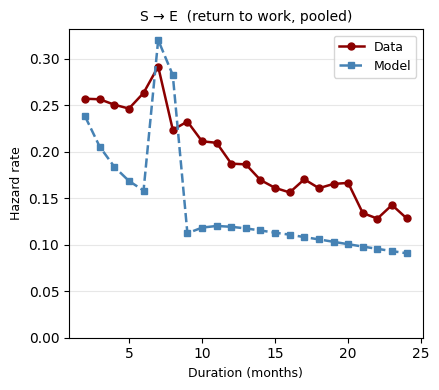

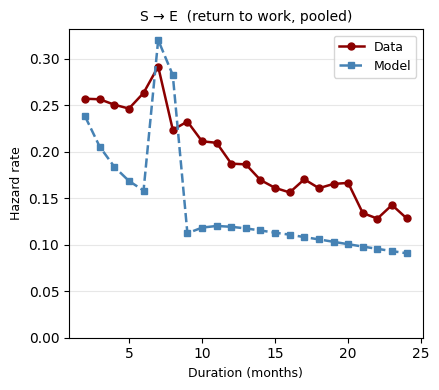

In [53]:
est.plot_fit(theta0, data_moments, ci_dict=ci_dict)

## 7. Run estimation
Nelder-Mead from `theta0`. If it converges to implausible values, try adjusting `theta0`.

In [54]:

result = est.estimate(
    data_moments,
    W              = W_se,
    theta0         = theta0,
    nm_maxiter     = 5000,
    progress_every = 5,
)
print(result['table'])


Nelder-Mead  (23 parameters)
  eval     5  |  best Q = 0.090394
  eval    10  |  best Q = 0.090394
  eval    15  |  best Q = 0.090394
  eval    20  |  best Q = 0.090394
  eval    25  |  best Q = 0.051730
  iter    26 evals  |  best Q = 0.048972
  iter    27 evals  |  best Q = 0.048972
  iter    28 evals  |  best Q = 0.048972
  iter    29 evals  |  best Q = 0.048972
  eval    30  |  best Q = 0.048972
  iter    30 evals  |  best Q = 0.048972
  iter    31 evals  |  best Q = 0.048972
  iter    32 evals  |  best Q = 0.048972
  iter    33 evals  |  best Q = 0.048972
  iter    34 evals  |  best Q = 0.048972
  eval    35  |  best Q = 0.048972
  iter    35 evals  |  best Q = 0.048972
  iter    36 evals  |  best Q = 0.048972
  iter    37 evals  |  best Q = 0.048972
  iter    38 evals  |  best Q = 0.048972
  iter    39 evals  |  best Q = 0.048972
  eval    40  |  best Q = 0.048972
  iter    40 evals  |  best Q = 0.048972
  iter    41 evals  |  best Q = 0.048972
  iter    42 evals  |  best Q = 0.0

/Users/sophiebune/Library/Mobile Documents/com~apple~CloudDocs/POLIT/Kandidat/Speciale/speciale/Code/Estimation.py:440: RuntimeWarning: Maximum number of iterations has been exceeded.
  "xatol":    1e-5,


                                        description   estimate  lower_bound  \
parameter                                                                     
psi                               job-finding scale   1.040406         0.05   
gamma                         search cost curvature   0.967968         0.30   
iota                      work disutility curvature   0.935274         0.30   
chi                  participation cost coefficient   1.012946         0.00   
rho_h                      health AR(1) persistence   0.883134         0.50   
sigma_h                        health shock std dev   0.299155         0.05   
delta_h_S       health recovery drift on sick leave   0.061458        -0.10   
delta0_doc                   medical gate intercept   0.149804        -0.20   
delta1_doc              medical gate slope (health)   0.909127        -1.00   
delta2_doc         medical gate curvature (health²)   0.000159        -2.00   
b_sick_low   intermediate benefit post-reassessment 

## 8. Simulated vs empirical hazards at estimates

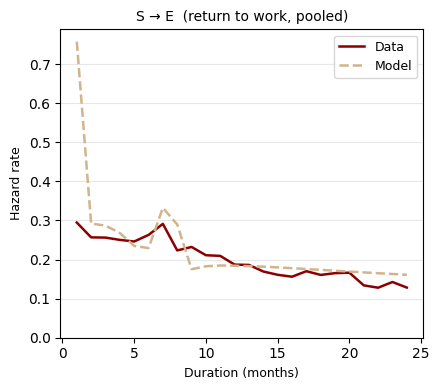

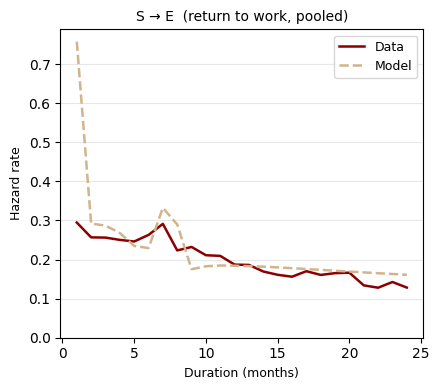

In [57]:
est.plot_fit(result['theta'], data_moments, ci_dict=ci_dict)

## 9. Moment fit table

In [ ]:
fit = moment_fit_table(est.compute_moments(result['theta']), data_moments)
display(fit)

,data,model,deviation,rel_dev_%
moment,,,,
hz_se_d02,0.256777,0.018386,-0.238390,-92.839598
hz_se_d03,0.256217,0.017731,-0.238486,-93.079687
hz_se_d04,0.250364,0.017017,-0.233347,-93.203230
hz_se_d05,0.246224,0.016390,-0.229834,-93.343613
hz_se_d06,0.263007,0.015771,-0.247236,-94.003750
hz_se_d07,0.291352,0.317941,0.026588,9.125828
hz_se_d08,0.223415,0.414914,0.191500,85.714877
hz_se_d09,0.232273,0.019787,-0.212486,-91.481103
hz_se_d10,0.211096,0.019278,-0.191818,-90.867593


## 10. Re-estimation with optimal weighting matrix
Once you have a good first-round estimate, compute the efficient weighting matrix W* = Ω⁻¹  
and re-estimate. This up-weights precisely measured moments and gives correct standard errors.

In [ ]:

# W_opt   = est.optimal_weight_matrix(result['theta'], data_moments, n_bootstrap=200)
# result2 = est.estimate(data_moments, W=W_opt, theta0=result['theta'])
# est.plot_fit(result2['theta'], data_moments)


## 11. Standard errors

In [ ]:
# table = est.results_table(result['theta'], data_moments=data_moments,
#                            W=W_se, compute_se=True)
# display(table)